# Problem Set 3
## Sagar Clemensen (fck916)
### 11/3-2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import tree
from sklearn.ensemble import AdaBoostClassifier

## Problem 1a

In [2]:
trainTest = pd.read_csv('earning_potential_train_test_AMAS_2026.txt', usecols=range(1,6))
trainTest["earning"] = trainTest["earning"].str.strip()
highEarners = trainTest[trainTest["earning"] == ">50K"]
lowEarners = trainTest[trainTest["earning"] == "<=50K"]
highEarners = highEarners.drop(columns=["earning"])
lowEarners = lowEarners.drop(columns=["earning"])
print("Number of high earners: ", len(highEarners))
print("Number of low earners: ", len(lowEarners))

Number of high earners:  1161
Number of low earners:  3639


In [3]:
trainTest

,age,education,gender,hours-per-week,earning
0,39,13,0,40,<=50K
1,50,13,0,13,<=50K
2,38,9,0,40,<=50K
3,53,7,0,40,<=50K
4,28,13,1,40,<=50K
...,...,...,...,...,...
4795,34,13,0,40,<=50K
4796,29,11,1,40,<=50K
4797,46,13,0,50,>50K
4798,36,9,0,40,<=50K


In [4]:
highTest = highEarners.values[:500]
lowTest = lowEarners.values[:500]
highTrain = highEarners.values[500:]
lowTrain = lowEarners.values[500:]
print(len(lowTrain), len(highTrain), len(lowTest), len(highTest))
highTrain

3139 661 500 500


array([[39, 14,  0, 40],
       [47, 11,  0, 40],
       [32, 12,  1, 40],
       ...,
       [30, 12,  0, 50],
       [58,  9,  0, 20],
       [46, 13,  0, 50]], shape=(661, 4))

In [5]:
X_train = np.vstack([lowTrain, highTrain])
y_train = np.concatenate([np.zeros(len(lowTrain)), np.ones(len(highTrain))])

clf = AdaBoostClassifier(
    estimator=tree.DecisionTreeClassifier(max_depth=3),
    n_estimators=500,
    learning_rate=0.3,
    random_state=42
)
clf.fit(X_train, y_train)


bdt_score_train = clf.decision_function(X_train)


X_test = np.vstack([lowTest, highTest])
y_test = np.concatenate([np.zeros(len(lowTest)), np.ones(len(highTest))])

bdt_score_test = clf.decision_function(X_test)


low_scores = bdt_score_test[y_test == 0]
high_scores = bdt_score_test[y_test == 1]

In [6]:
from sklearn.model_selection import cross_val_score
X = np.vstack([lowEarners.values, highEarners.values])
y = np.concatenate([np.zeros(len(lowEarners)), np.ones(len(highEarners))])
scores = cross_val_score(clf, X, y, cv=5)
print(scores.mean(), scores.std())

0.8018750000000001 0.009114434522594741


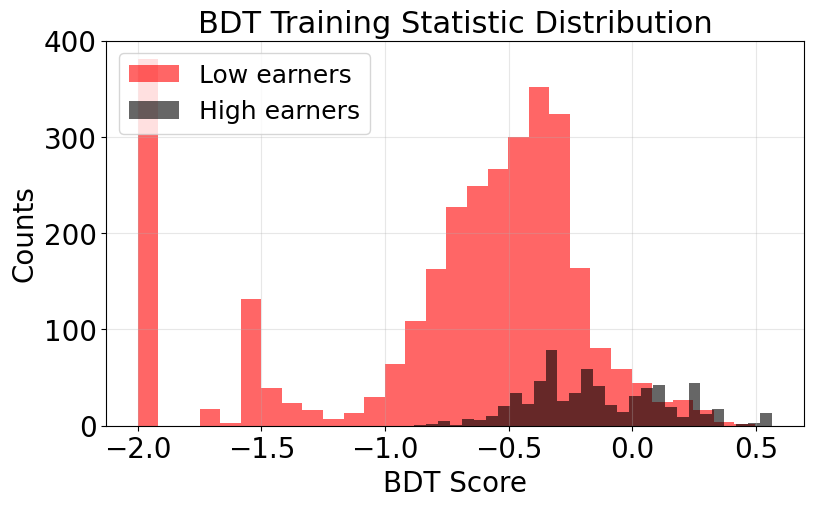

In [7]:
low_scores_train = bdt_score_train[y_train == 0]
high_scores_train = bdt_score_train[y_train == 1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(low_scores_train, bins=30, alpha=0.6, label='Low earners', color='red')
ax.hist(high_scores_train, bins=30, alpha=0.6, label='High earners', color='black')
ax.set_xlabel("BDT Score", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
ax.set_title("BDT Training Statistic Distribution", fontsize=22)
ax.tick_params(labelsize=20)
ax.legend(fontsize=18)
ax.grid(alpha=0.3);

In [8]:
thresholds = np.linspace(min(bdt_score_test), max(bdt_score_test), 200)

best_acc = 0
best_t = 0

for t in thresholds:
    y_pred = (bdt_score_test > t).astype(int)
    acc = np.mean(y_pred == y_test)

    if acc > best_acc:
        best_acc = acc
        best_t = t

print(best_t, best_acc)

-0.4143963840698115 0.768


In [9]:
y_pred_test = (bdt_score_test > best_t).astype(int)

accuracy = np.mean(y_pred_test == y_test)
print("Test accuracy:", accuracy)

Test accuracy: 0.768


In [10]:
TP = np.sum((y_pred_test == 1) & (y_test == 1))
TN = np.sum((y_pred_test == 0) & (y_test == 0))
FP = np.sum((y_pred_test == 1) & (y_test == 0))
FN = np.sum((y_pred_test == 0) & (y_test == 1))

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
accuracy = (TP + TN) / len(y_test)
print("Test accuracy:", accuracy)

TP: 431
TN: 337
FP: 163
FN: 69
Test accuracy: 0.768


In [11]:
print(np.min(low_scores), np.max(low_scores), np.min(high_scores), np.max(high_scores))

-2.000000000000002 0.3190388136896919 -1.5020025175247405 0.5653261753667292


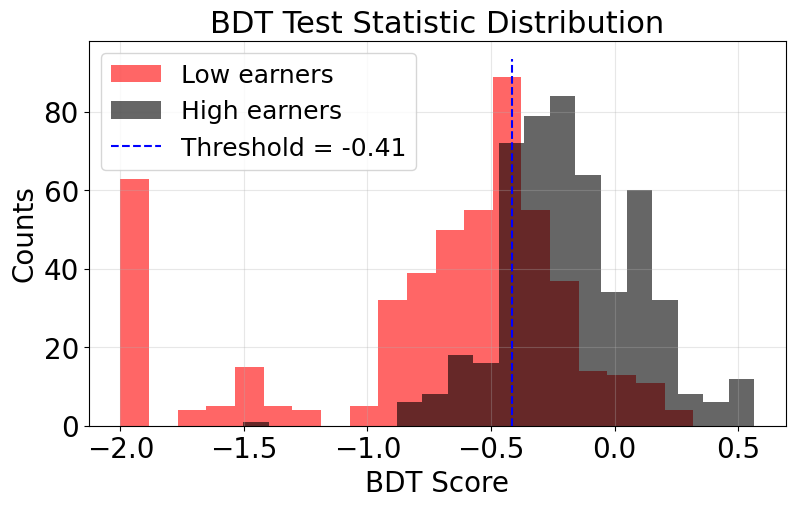

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(low_scores, bins=20, alpha=0.6, label='Low earners', color='red')
ax.hist(high_scores, bins=20, alpha=0.6, label='High earners', color='black')
ax.vlines(best_t, ymin=0, ymax=ax.get_ylim()[1], color='blue', linestyle='--', label=f'Threshold = {best_t:.2f}')
ax.set_xlabel("BDT Score", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
ax.set_title("BDT Test Statistic Distribution", fontsize=22)
ax.tick_params(labelsize=20)
ax.legend(fontsize=18)
ax.grid(alpha=0.3);

## Problem 1b

In [13]:
lowFrac = len(lowTrain) / (len(lowTrain) + len(highTrain))
highFrac = len(highTrain) / (len(lowTrain) + len(highTrain))
print(f"Low fraction: {lowFrac:.3f}, High fraction: {highFrac:.3f}")

Low fraction: 0.826, High fraction: 0.174


## Problem 1c

In [14]:
realData = pd.read_csv('earning_potential_real_2026.txt')
IDs = realData["ID"].values
realData

,ID,age,education,gender,hours-per-week
0,0,39,9,1,40
1,1,23,9,0,40
2,2,30,13,0,35
3,3,30,13,1,40
4,4,20,10,0,40
...,...,...,...,...,...
6507,6507,40,10,0,60
6508,6508,49,14,0,45
6509,6509,31,6,0,40
6510,6510,42,10,1,30


In [15]:
realDataTest = realData.drop(columns=["ID"]).values
realDataTest

array([[39,  9,  1, 40],
       [23,  9,  0, 40],
       [30, 13,  0, 35],
       ...,
       [31,  6,  0, 40],
       [42, 10,  1, 30],
       [47, 13,  0, 70]], shape=(6512, 4))

In [16]:
bdt_score_real = clf.decision_function(realDataTest)

In [17]:
lowEarnersReal = IDs[bdt_score_real <= best_t]
highEarnersReal = IDs[bdt_score_real > best_t]
print("Low earners in real data:", len(lowEarnersReal))
print("High earners in real data:", len(highEarnersReal))
np.savetxt("sagar_clemensen.low_ID.txt", lowEarnersReal)
np.savetxt("sagar_clemensen.high_ID.txt", highEarnersReal)

Low earners in real data: 3329
High earners in real data: 3183


## Problem 2a

In [4]:
df = pd.read_csv('cpd_crash_incidents.csv', sep=";")
headers = df.columns.tolist()
df

,tamainid,location_description,rdfeature,rdcharacter,rdclass,rdconfigur,rdsurface,rdcondition,lightcond,weather,...,fatalities,injuries,month,contrfact1,contrfact2,contributing_factor,vehicleconcat1,vehicleconcat2,vehicleconcat3,vehicle_type
0,20603,140 FEET FROM PVA (2234 WALNUT ST),NO SPECIAL FEATURE,"STRAIGHT,LEVEL",PUBLIC VEHICULAR AREA,"TWO-WAY,NOT DIVIDED",SMOOTH ASPHALT,DRY,DAYLIGHT,CLOUDY,...,No,No,1,NaN,NONE,NONE,"PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY"
1,20606,.10 MILES FROM PVA OF 150 WRENN DR,NO SPECIAL FEATURE,"STRAIGHT,LEVEL",PUBLIC VEHICULAR AREA,"ONE-WAY,NOT DIVIDED",SMOOTH ASPHALT,DRY,DAYLIGHT,CLEAR,...,No,No,1,NaN,NONE,NONE,"SPORT UTILITY,VAN","SPORT UTILITY,VAN","SPORT UTILITY,VAN","SPORT UTILITY,VAN"
2,20607,30 FEET FROM SR1300(KILDAIRE FARM RD),RELATED TO INTERSECTION,"STRAIGHT,LEVEL",STATE SECONDARY ROUTE,"TWO-WAY,DIVIDED,UNPROTECTED MEDIAN",SMOOTH ASPHALT,DRY,DAYLIGHT,CLEAR,...,No,No,1,NaN,NONE,NONE,"PASSENGER CAR,PASSENGER CAR","PASSENGER CAR,PASSENGER CAR","PASSENGER CAR,PASSENGER CAR","PASSENGER CAR,PASSENGER CAR"
3,20609,35 FEET FROM NC 54 HWY (NW MAYNARD RD),RELATED TO INTERSECTION,"STRAIGHT,LEVEL",NC ROUTE,"TWO-WAY,DIVIDED,UNPROTECTED MEDIAN",COARSE ASPHALT,DRY,DAYLIGHT,CLEAR,...,No,No,1,NaN,NONE,NONE,"PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY"
4,20628,300 FEET FROM US 64 HWY,RELATED TO INTERSECTION,"STRAIGHT,GRADE",US ROUTE,"TWO-WAY,DIVIDED,UNPROTECTED MEDIAN",SMOOTH ASPHALT,DRY,DAYLIGHT,CLOUDY,...,No,No,1,NaN,NONE,NONE,"VAN,PASSENGER CAR","VAN,PASSENGER CAR","VAN,PASSENGER CAR","VAN,PASSENGER CAR"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23453,47069,CARY,FOUR-WAY INTERSECTION,"STRAIGHT,LEVEL",STATE SECONDARY ROUTE,"TWO-WAY,NOT DIVIDED",SMOOTH ASPHALT,DRY,DAYLIGHT,CLEAR,...,No,Yes,3,NONE,"NONE,NONE","NONE,NONE","PASSENGER CAR,PASSENGER CAR","PASSENGER CAR,PASSENGER CAR","PASSENGER CAR,PASSENGER CAR","PASSENGER CAR,PASSENGER CAR"
23454,47070,CARY,FOUR-WAY INTERSECTION,"STRAIGHT,LEVEL",STATE SECONDARY ROUTE,"TWO-WAY,DIVIDED,UNPROTECTED MEDIAN",SMOOTH ASPHALT,DRY,DARK - LIGHTED ROADWAY,CLEAR,...,No,Yes,3,NaN,NONE,NONE,"VAN,PASSENGER CAR","VAN,PASSENGER CAR,PASSENGER CAR","VAN,PASSENGER CAR,PASSENGER CAR","VAN,PASSENGER CAR,PASSENGER CAR"
23455,47077,.314 MILES FROM P.V.A. 275 CONVENTION DR,NaN,NaN,PUBLIC VEHICULAR AREA,"ONE-WAY,NOT DIVIDED",SMOOTH ASPHALT,DRY,DAYLIGHT,CLEAR,...,No,No,3,NaN,NONE,NONE,"UNKNOWN,PASSENGER CAR","UNKNOWN,PASSENGER CAR","UNKNOWN,PASSENGER CAR","UNKNOWN,PASSENGER CAR"
23456,47079,CARY,FOUR-WAY INTERSECTION,"STRAIGHT,GRADE",STATE SECONDARY ROUTE,"TWO-WAY,NOT DIVIDED",SMOOTH ASPHALT,DRY,DAYLIGHT,CLEAR,...,No,No,3,NONE,"NONE,NONE","NONE,NONE","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY","PASSENGER CAR,SPORT UTILITY"


In [5]:
latitude = df['lat'].values.copy()
cleanLatitude = latitude[~np.isnan(latitude)]

longitude = df['lon'].values.copy()
cleanLongitude = longitude[~np.isnan(longitude)]

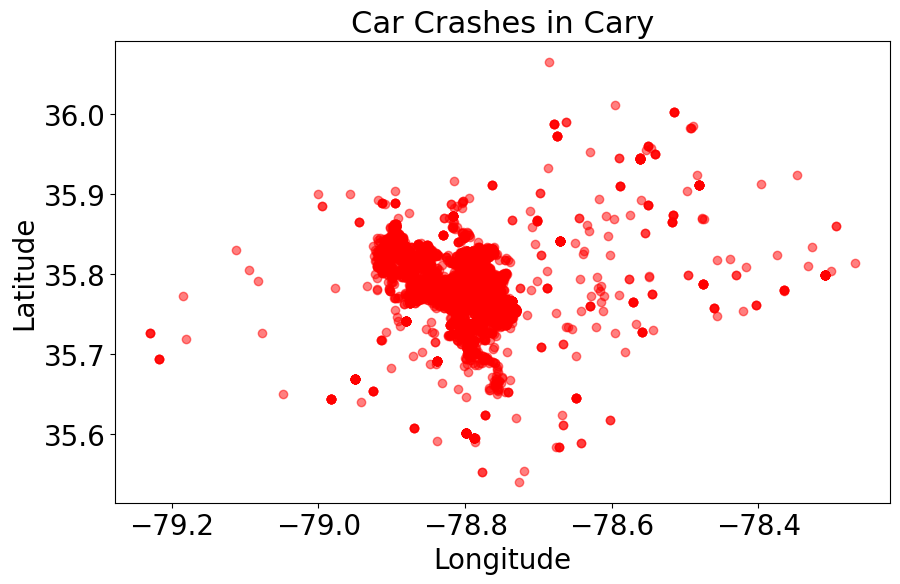

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(cleanLongitude, cleanLatitude, alpha=0.5, color='red')
ax.set_title('Car Crashes in Cary', fontsize=22)
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20);

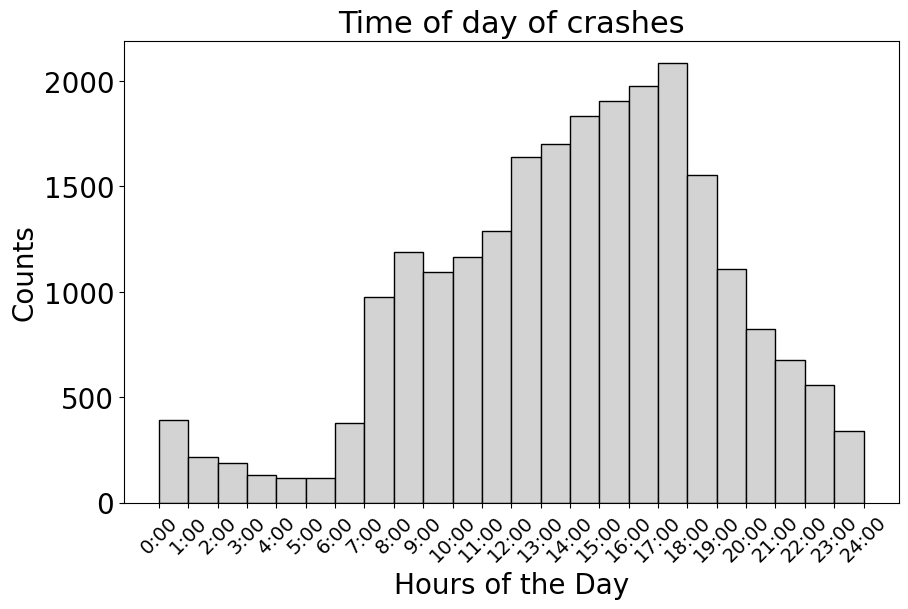

In [10]:
df['ta_time_parsed'] = pd.to_datetime(df['ta_time'], format='%I:%M:%S %p', errors='coerce')
df['ta_time_parsed'] = df['ta_time_parsed'].fillna(pd.to_datetime(df['ta_time'], format='%I:%M %p', errors='coerce'))

df['ta_seconds'] = (df['ta_time_parsed'].dt.hour * 3600 + df['ta_time_parsed'].dt.minute * 60 + df['ta_time_parsed'].dt.second)

crashSeconds = df['ta_seconds'].values
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(crashSeconds, bins=24, range=(0, 24*3600), color = 'lightgray', edgecolor='black')
ax.set_title('Time of day of crashes', fontsize=22)
ax.set_xlabel('Hours of the Day', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_xticks(np.arange(0, 24*3600 + 1, 3600))
ax.set_xticklabels([f'{h}:00' for h in range(25)], rotation=45)
ax.tick_params(axis='y', which='major', labelsize=20);
ax.tick_params(axis='x', which='major', labelsize=14);

## Problem 2b

In [11]:
def KDE_Epanechnikov(x, data, h):
    x = np.asarray(x)
    yvals = np.zeros_like(x)
    for i, xi in enumerate(x):
        N = len(data)
        u = (xi-data)/h
        K = np.zeros(N)
        K[np.abs(u)<=1]=0.75*(1-u[np.abs(u)<=1]**2)/h
        yvals[i] = np.sum(K)/N
    return yvals

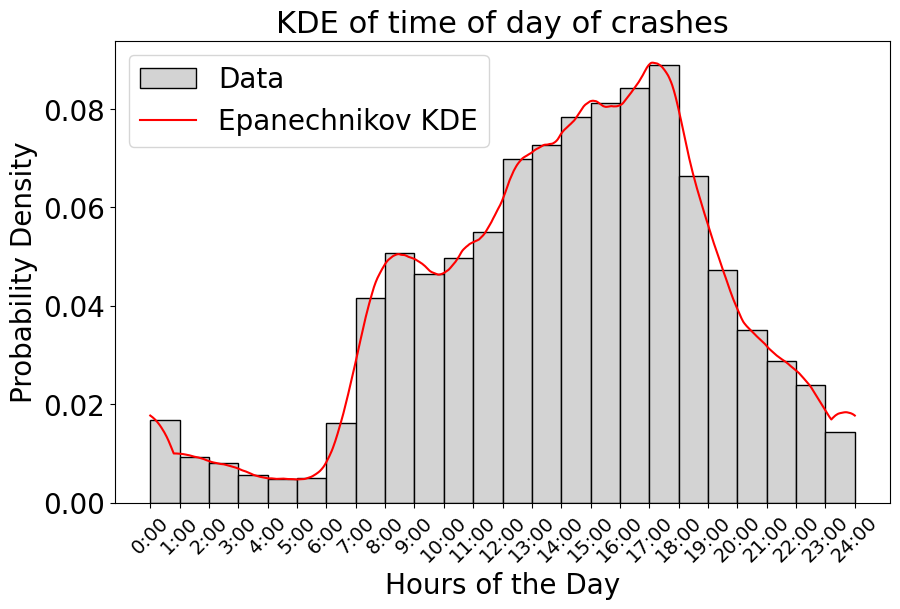

In [12]:
xtimes = np.linspace(0, 24, 1201)
crashHours = crashSeconds/3600
kde_values = KDE_Epanechnikov(xtimes, np.concatenate([crashHours - 24, crashHours, crashHours + 24]), h=0.8)
NormConst = np.sum(kde_values)*(xtimes[1]-xtimes[0])
kde_values /= NormConst
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(crashHours, bins=24, range=(0, 24), density=True, color = 'lightgray', edgecolor='black', label='Data')
ax.plot(xtimes, kde_values, color='red', label='Epanechnikov KDE')
ax.set_title('KDE of time of day of crashes', fontsize=22)
ax.set_xlabel('Hours of the Day', fontsize=20)
ax.set_ylabel('Probability Density', fontsize=20)
ax.set_xticks(np.arange(0, 24 + 1, 1))
ax.set_xticklabels([f'{h}:00' for h in range(25)], rotation=45)
ax.tick_params(axis='y', which='major', labelsize=20)
ax.tick_params(axis='x', which='major', labelsize=14)
ax.legend(fontsize=20);

In [13]:
def timeConverter(hours, minutes):
    return hours + minutes/60

In [15]:
times = np.array([timeConverter(0, 23), timeConverter(1, 49), timeConverter(8, 12), timeConverter(15, 55), timeConverter(18, 2), timeConverter(21, 12), timeConverter(23, 44)])
Probs = 3*KDE_Epanechnikov(times, np.concatenate([crashHours - 24, crashHours, crashHours + 24]), h=0.8)
for t, p in zip(times, Probs):
    time = f"{int(t)}:{int((t-int(t))*60):02d}"
    print(f"Time: {time}, f(time): {p:.4f}")

Time: 0:23, f(time): 0.0152
Time: 1:49, f(time): 0.0089
Time: 8:11, f(time): 0.0498
Time: 15:54, f(time): 0.0806
Time: 18:02, f(time): 0.0790
Time: 21:11, f(time): 0.0307
Time: 23:44, f(time): 0.0184


In [16]:
dx = xtimes[1] - xtimes[0]
print(f'dx = {dx}')
integral_tot = np.sum(kde_values) * dx
print(f"Integral of KDE over 24 hours: {integral_tot:.6f}")

dx = 0.02
Integral of KDE over 24 hours: 1.000000


In [17]:
points = 100
best_i = 0
biggest_integral = 0
for i in range(len(xtimes)):
    i0 = i
    i1 = (i + points) % len(xtimes)
    yvals = kde_values[i0:i1] if i1 > i0 else np.concatenate([kde_values[i0:], kde_values[:i1]])
    integral = np.sum(yvals) * dx
    if integral > biggest_integral:
        biggest_integral = integral
        best_i = i
print(f"Best time window: {xtimes[best_i]:.2f} to {xtimes[best_i+points]:.2f} hours, Integral: {biggest_integral:.6f}")

Best time window: 15.98 to 17.98 hours, Integral: 0.171446


In [18]:
best_time0 = f"{int(xtimes[best_i])}:{int((xtimes[best_i]-int(xtimes[best_i]))*60):02d}"
best_time1 = f"{int(xtimes[best_i+points])}:{int((xtimes[best_i+points]-int(xtimes[best_i+points]))*60):02d}"

In [19]:
change = biggest_integral*0.1
print(f"The best time window to patrol is from {best_time0} to {best_time1} hours resulting in a total decrease in crash probability of {change*100:.2f}%")

The best time window to patrol is from 15:58 to 17:58 hours resulting in a total decrease in crash probability of 1.71%


In [21]:
1.71/(10/12)

2.052

## Problem 2c

In [22]:
from numba import njit
@njit
def KDE_Epanechnikov2D_numba(x, y, X, Y, hx, hy):
    n = len(X)
    s = 0.0
    
    for k in range(n):
        u = (x - X[k]) / hx
        v = (y - Y[k]) / hy
        
        r2 = u*u + v*v
        
        if r2 < 1.0:
            s += (2.0 / np.pi) * (1.0 - r2)
            
    return s / (n * hx * hy)


@njit
def compute_grid(xvals, yvals, X, Y, hx, hy):
    nx = len(xvals)
    ny = len(yvals)
    P = np.zeros((nx, ny))
    
    for i in range(nx):
        for j in range(ny):
            P[i, j] = KDE_Epanechnikov2D_numba(xvals[i], yvals[j], X, Y, hx, hy)
            
    return P

In [23]:
# Precompute grid
xvals = np.linspace(np.min(cleanLongitude), np.max(cleanLongitude), 500)
yvals = np.linspace(np.min(cleanLatitude), np.max(cleanLatitude), 500)

# Compute KDE grid
P = compute_grid(xvals, yvals, cleanLongitude, cleanLatitude, hx=0.01, hy=0.01)

dx = xvals[1] - xvals[0]
dy = yvals[1] - yvals[0]

# Normalize
normConst = np.sum(P) * dx * dy
print(f"Normalization constant for P: {normConst:.6f}")
P /= normConst

Normalization constant for P: 0.999621


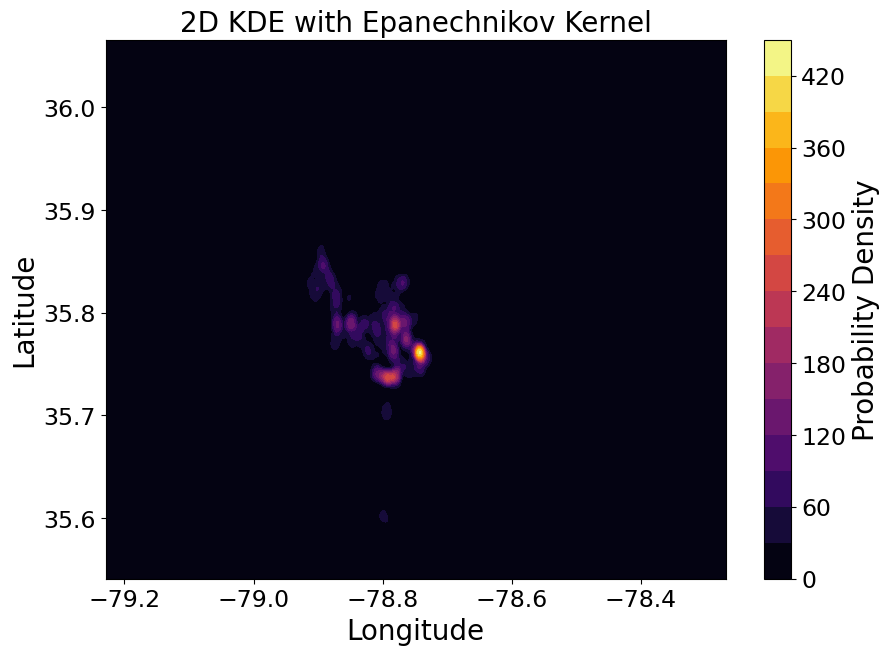

In [25]:
fig, ax = plt.subplots(figsize=(10,7))
cp = ax.contourf(xvals, yvals, P.T, levels=15, cmap='inferno')
ax.set_xlabel("Longitude", fontsize=20)
ax.set_ylabel("Latitude", fontsize=20)
ax.set_title("2D KDE with Epanechnikov Kernel", fontsize=20)
ax.tick_params(axis='both', labelsize=17)
cbar = plt.colorbar(cp, ax=ax)
cbar.set_label("Probability Density", fontsize=20)
cbar.ax.tick_params(labelsize=17)

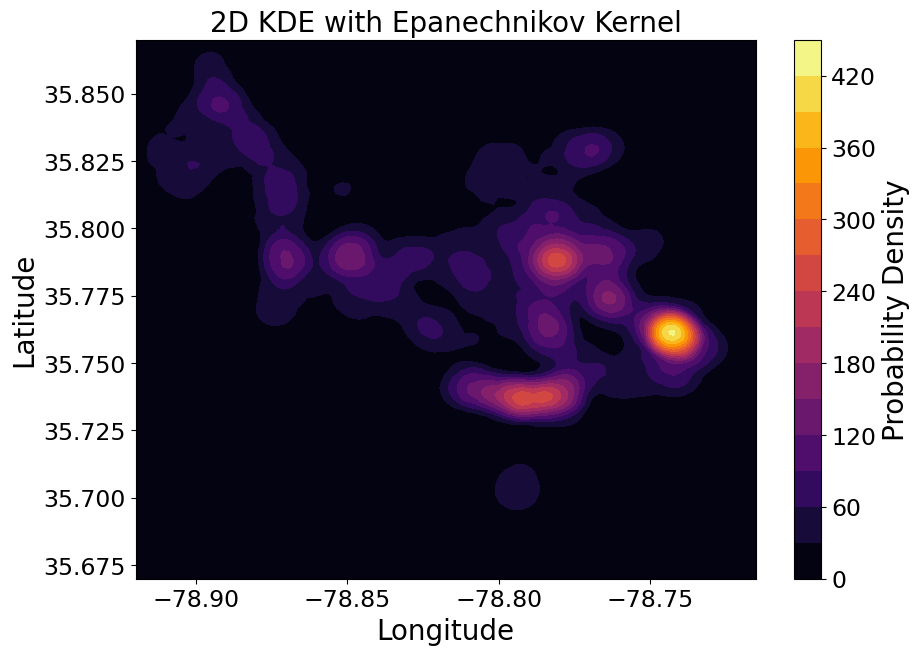

In [26]:
fig, ax = plt.subplots(figsize=(10,7))
cp = ax.contourf(xvals, yvals, P.T, levels=15, cmap='inferno')
ax.set_xlabel("Longitude", fontsize=20)
ax.set_ylabel("Latitude", fontsize=20)
ax.set_title("2D KDE with Epanechnikov Kernel", fontsize=20)
ax.tick_params(axis='both', labelsize=17)
ax.set_xlim(-78.92, -78.715)
ax.set_ylim(35.67, 35.87)
cbar = plt.colorbar(cp, ax=ax)
cbar.set_label("Probability Density", fontsize=20)
cbar.ax.tick_params(labelsize=17)

In [31]:
x0 = -78.76
x1 = -78.72
y0 = 35.74
y1 = 35.78

# Precompute grid
xvals0 = np.linspace(x0, x1, 500)
yvals0 = np.linspace(y0, y1, 500)

# Compute KDE grid
P0 = compute_grid(xvals0, yvals0, cleanLongitude, cleanLatitude, hx=0.01, hy=0.01)

dx0 = xvals0[1] - xvals0[0]
dy0 = yvals0[1] - yvals0[0]

In [32]:
# Probability in the region
prob0 = np.sum(P0) * dx0 * dy0
print(f"Estimated probability of a crash in the region ({x0}, {y0}) to ({x1}, {y1}): {prob0*100:.6f}%")

Estimated probability of a crash in the region (-78.76, 35.74) to (-78.72, 35.78): 13.735407%


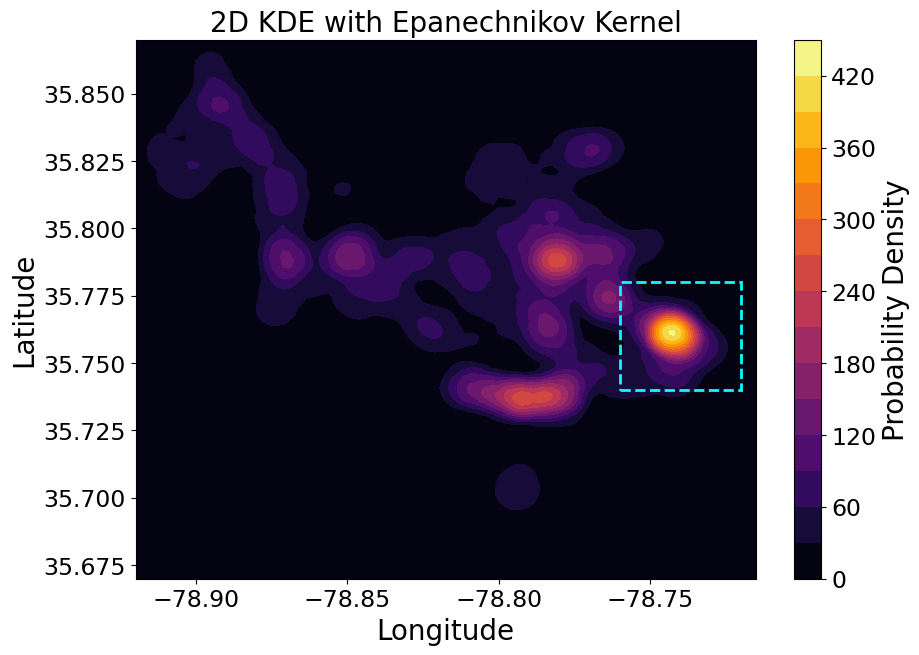

In [34]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10,7))
cp = plt.contourf(xvals, yvals, P.T, levels=15, cmap='inferno')
# Add rectangle for the region of interest
rect = patches.Rectangle(
    (x0, y0),          # lower-left corner
    x1 - x0,           # width
    y1 - y0,           # height
    linewidth=2,
    edgecolor='cyan',
    facecolor='none',
    linestyle='--'
)
ax.add_patch(rect)
ax.set_xlabel("Longitude", fontsize=20)
ax.set_ylabel("Latitude", fontsize=20)
ax.set_title("2D KDE with Epanechnikov Kernel", fontsize=20)
ax.tick_params(axis='both', labelsize=17)
ax.set_xlim(-78.92, -78.715)
ax.set_ylim(35.67, 35.87)
cbar = plt.colorbar(cp)
cbar.set_label("Probability Density", fontsize=20)
cbar.ax.tick_params(labelsize=17)
plt.show()

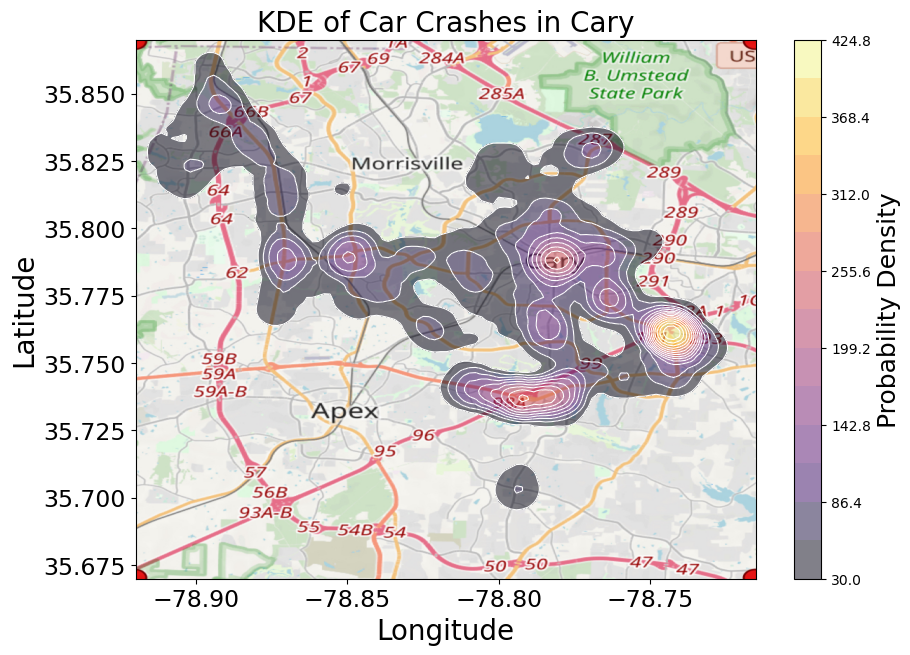

In [35]:
import matplotlib.image as mpimg

fig, ax = plt.subplots(figsize=(10,7))

# Load map screenshot
img = mpimg.imread("cary.jpg")

# Show background map
ax.imshow(
    img,
    extent=[-78.92, -78.715, 35.67, 35.87],
    aspect='auto'
)

# Choose only some contour levels
levels = np.linspace(30, np.max(P), 15)

# Semi-transparent filled contours
cf = ax.contourf(
    xvals, yvals, P.T,
    levels=levels,
    cmap="inferno",
    alpha=0.5
)

# Contour lines (major ones only)
cl = ax.contour(
    xvals, yvals, P.T,
    levels=levels,
    colors="white",
    linewidths=0.8
)

# # Optional contour labels
# ax.clabel(cl, inline=True, fontsize=10, fmt="%.3f")

ax.set_xlim(-78.92, -78.715)
ax.set_ylim(35.67, 35.87)

ax.set_xlabel("Longitude", fontsize=20)
ax.set_ylabel("Latitude", fontsize=20)
ax.set_title("KDE of Car Crashes in Cary", fontsize=20)

ax.tick_params(axis='both', labelsize=17)

cbar = plt.colorbar(cf)
cbar.set_label("Probability Density", fontsize=18)

plt.show()

## Problem 3a

### $P(A_i|D) = \frac{P(D|A_i)P(A_i)}{P(D)}$
### $P(D) = \sum_{i=1}^n P(D|A_i)P(A_i)$

In [ ]:
def PA_nD(PA, PDA_N, PD):
    return PDA_N * PA / PD

In [ ]:
data = {
    "Facility": ["A1", "A2", "A3", "A4", "A5"],
    "Production": np.array([35, 15, 5, 20, 25])/100,
    "Defective": np.array([2, 4, 10, 3.5, 3.1])/100
}

df = pd.DataFrame(data)
print(df)
PD = np.sum(df['Production'] * df['Defective'])
print('P(D) =',PD)
Pval = 0
for i, (PA, PDA) in enumerate(zip(df["Production"],df["Defective"])):
    PAiD = PA_nD(PA, PDA, PD)
    Pval += PAiD
    print(f"P(A_{i+1}|D) = {PAiD:.5f}")
print(f"Sum of P(A_i|D): {Pval}")

  Facility  Production  Defective
0       A1        0.35      0.020
1       A2        0.15      0.040
2       A3        0.05      0.100
3       A4        0.20      0.035
4       A5        0.25      0.031
P(D) = 0.03275
P(A_1|D) = 0.21374
P(A_2|D) = 0.18321
P(A_3|D) = 0.15267
P(A_4|D) = 0.21374
P(A_5|D) = 0.23664
Sum of P(A_i|D): 1.0


### $P(A_i|D) = \frac{P(D|A_i)P(A_i)}{P(D)}$ =0.2 $\forall$ $i$  since there are 5 facilities $A_i$ and the probabilities must sum to 1.

In [ ]:
df['5pd'] = 5*df['Production'] * df['Defective']
S = np.max(df['5pd'].values)
df['New_Defective'] = S/(5*df['Production'])
df['Changed_Defective'] = df['New_Defective'] - df['Defective']
df

,Facility,Production,Defective,5pd,New_Defective,Changed_Defective
0,A1,0.35,0.020,0.03500,0.022143,0.002143
1,A2,0.15,0.040,0.03000,0.051667,0.011667
2,A3,0.05,0.100,0.02500,0.155000,0.055000
3,A4,0.20,0.035,0.03500,0.038750,0.003750
4,A5,0.25,0.031,0.03875,0.031000,0.000000


In [ ]:
PDNew = np.sum(df['Production'] * df['New_Defective'])
print(np.sum(df['Production'] * df['New_Defective']), np.sum(df['Production'] * df['Defective']))
print('P(D) =',PDNew)
Pval = 0
for i, (PA, PDA) in enumerate(zip(df["Production"],df["New_Defective"])):
    PAiD = PA_nD(PA, PDA, PDNew)
    Pval += PAiD
    print(f"P(A_{i+1}|D) = {PAiD:.4f}")
print(f"Sum of P(A_i|D): {Pval}")

0.03875 0.03275
P(D) = 0.03875
P(A_1|D) = 0.2000
P(A_2|D) = 0.2000
P(A_3|D) = 0.2000
P(A_4|D) = 0.2000
P(A_5|D) = 0.2000
Sum of P(A_i|D): 1.0


## Problem 4a

In [ ]:
Remodeler = pd.read_csv('Remodeler_Landscape.csv')
Remodeler
pos = Remodeler['Position'].values
pot = Remodeler['Potential'].values
def Vfunc(pos):
    return 

In [ ]:
r = np.random

In [ ]:
valid_pos = pos[pos%1==0]
N = len(valid_pos)

def mcmc_nucleosome(beta, checkpoints, steps=500_000, burn_in=5000, x0=10):
    current_pos = x0
    snapshots = np.zeros((len(checkpoints), N))
    counts = np.zeros(N)

    trial_distributions = {int(p): [] for p in valid_pos}
    trials_here = 0

    for step in range(steps):
        trials_here += 1

        direction = r.choice([-1, 1])
        barrier_pos = (current_pos + 0.5 * direction) % N

        # Metropolis acceptance
        dV = pot[np.argwhere(pos==barrier_pos)] - pot[np.argwhere(pos==current_pos)]
        accept_prob = min(1, np.exp(-beta * dV))

        if r.rand() < accept_prob:
            new_pos = (current_pos + direction) % N
            #record how many trials it took to leave current_pos
            trial_distributions[current_pos].append(trials_here)

            #move
            current_pos = new_pos

            #reset counter for new position
            trials_here = 0
        
        idx = np.argwhere(valid_pos == current_pos)
        counts[idx] += 1
        
        if step in checkpoints:
            idx = np.argwhere(valid_pos == current_pos)
            snapshots[checkpoints.index(step)] = counts / np.sum(counts)
            
        if step == burn_in:
            counts = np.zeros(N) #Wipe counts after burn-in
            idx = np.argwhere(valid_pos == current_pos)
            counts[idx] += 1

    counts /= np.sum(counts) #Normalize 
    return counts, snapshots, trial_distributions

In [ ]:
r.seed(42)
betas = [0.01, 0.1, 1]
sampled_distributions = []
sampled_snaps = []
trial_distributions = []
checkpoints=[1000, 50_000]
for beta in betas:
    sampled, snaps, trials = mcmc_nucleosome(beta, checkpoints=checkpoints)
    sampled_distributions.append(sampled)
    sampled_snaps.append(snaps)
    trial_distributions.append(trials)

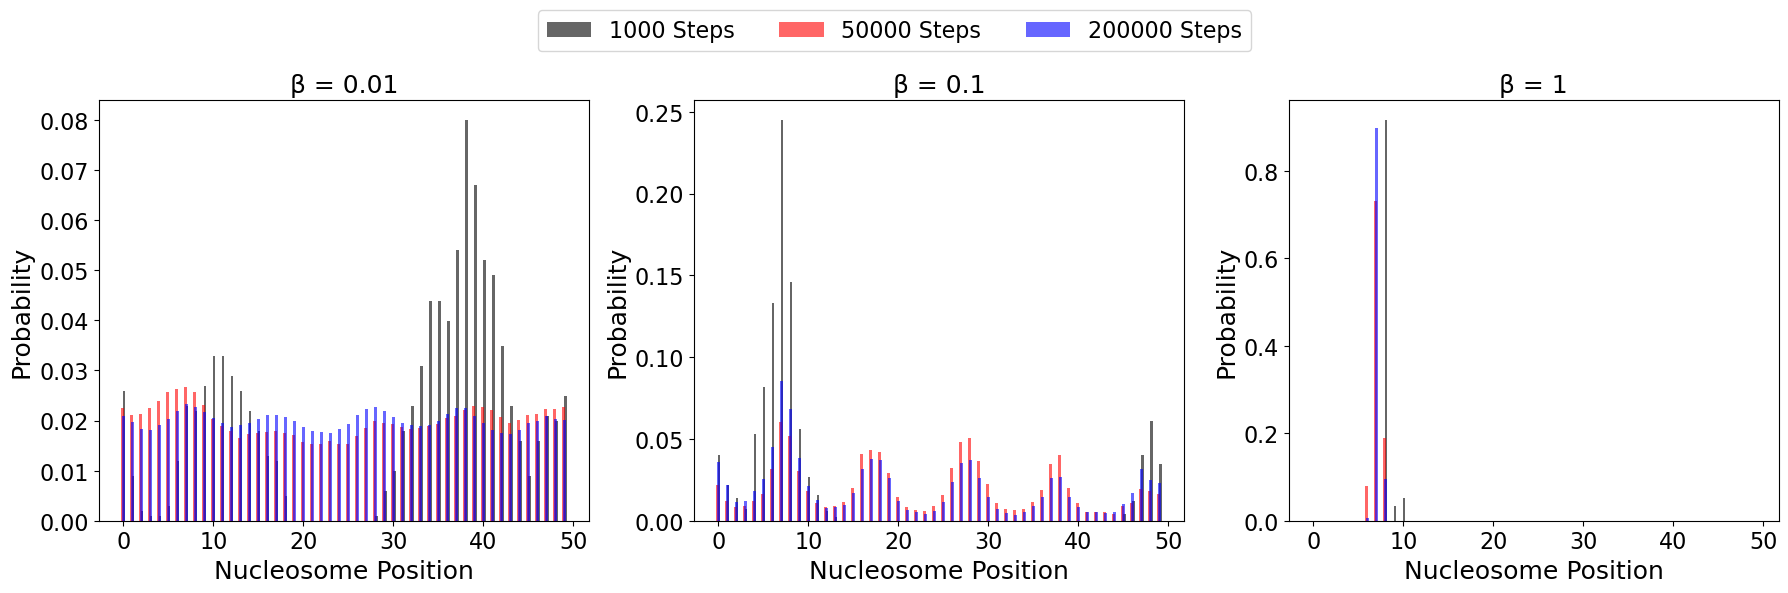

In [ ]:
colors = ['blue', 'black', 'red']
fig, ax = plt.subplots(1, len(betas), figsize=(18, 6))
for i, beta in enumerate(betas):    
    x = valid_pos
    sampled = sampled_distributions[i]
    snaps = sampled_snaps[i]
    bar2 = ax[i].bar(x+0.1, snaps[0], width=0.3, label=f'{checkpoints[0]} Steps', color=colors[1], alpha=0.6)
    bar3 = ax[i].bar(x-0.1, snaps[1], width=0.3, label=f'{checkpoints[1]} Steps', color=colors[2], alpha=0.6)
    bar1 = ax[i].bar(x, sampled, width=0.3, color = colors[0], label ='200000 Steps', alpha=0.6)
    ax[i].set_title(f"β = {beta}", fontsize=18)
    ax[i].set_xlabel("Nucleosome Position", fontsize=18)
    ax[i].set_ylabel("Probability", fontsize=18)
    ax[i].tick_params(labelsize=16)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=16)

plt.tight_layout(rect=[0, 0,1 , 0.9])
plt.show()

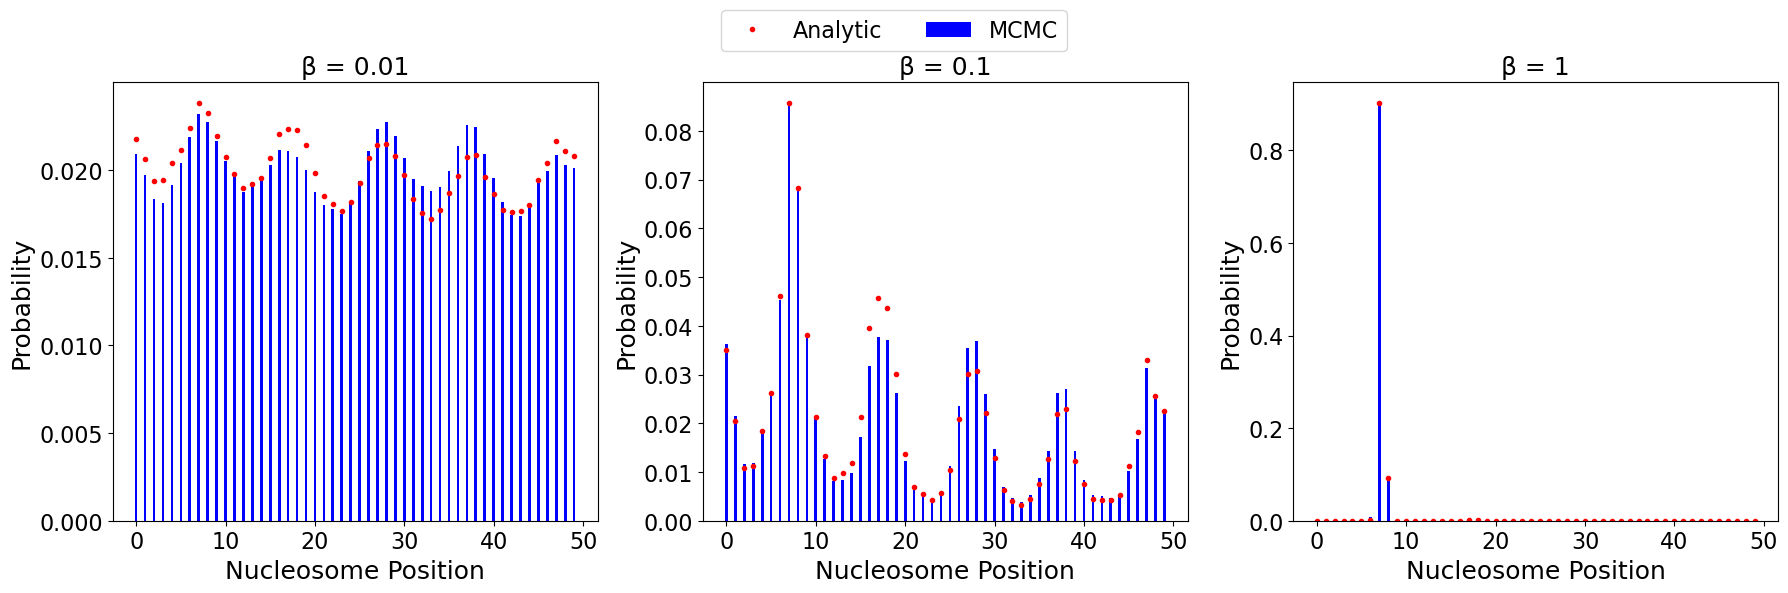

In [ ]:
valid_pos_indices = np.where(pos % 1 == 0)[0]
def theoretical_distribution(beta):
    p_int = np.exp(-beta * pot[valid_pos_indices])
    return p_int / np.sum(p_int)

fig, ax = plt.subplots(1, len(betas), figsize=(18,6))

for i, beta in enumerate(betas):
    sampled = sampled_distributions[i]
    analytic = theoretical_distribution(beta)
    x = valid_pos
    bar_container = ax[i].bar(x, sampled, width=0.3, color='blue', label="MCMC")
    line_plot, = ax[i].plot(x, analytic, '.', color='red', label="Analytic")
    ax[i].set_title(f"β = {beta}", fontsize=18)
    ax[i].set_xlabel("Nucleosome Position", fontsize=18)
    ax[i].set_ylabel("Probability", fontsize=18)
    ax[i].tick_params(labelsize=16)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=16)

plt.tight_layout(rect=[0, 0,1 , 0.93])
plt.show()

In [ ]:
len(trial_distributions)

3

In [ ]:
np.unique(trial_distributions[0][0])

array([1, 2, 3, 4, 5, 6])

In [ ]:
valid_pos

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49.])

In [ ]:
lower_p = 15.865
upper_p = 84.135
medians = np.zeros((3, len(valid_pos)))
CI_lows = np.zeros((3, len(valid_pos)))
CI_highs = np.zeros((3, len(valid_pos)))
for i, trial in enumerate(trial_distributions):
    for j in range(len(trial)):
        if len(trial[j]) == 0:
            continue
        median = np.median(trial[j])
        CILow, CIHigh = np.percentile(trial[j], [lower_p, upper_p])
        medians[i, j] = median
        CI_lows[i, j] = CILow
        CI_highs[i, j] = CIHigh

In [ ]:
medians[2]

array([    0.,     0.,     0.,     0.,     0.,     0.,  3573., 18115.,
       11841.,    19.,    52.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.])

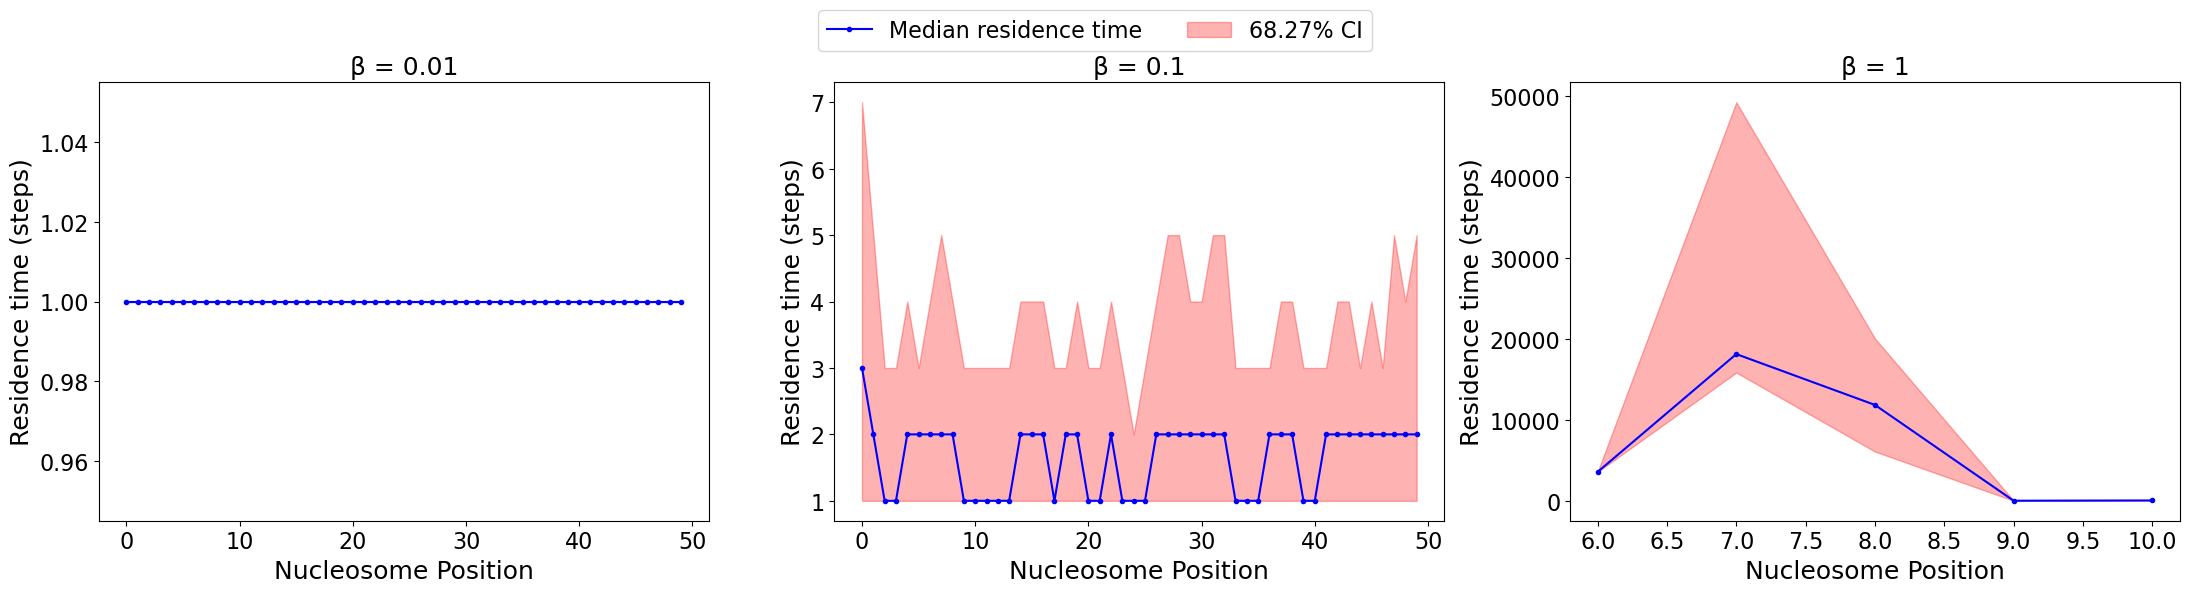

In [ ]:
fig, ax = plt.subplots(1, len(betas), figsize=(22,6))
for i, beta in enumerate(betas):
    mask = medians[i] > 0
    line_plot = ax[i].plot(valid_pos[mask], medians[i][mask], '.-', color='blue', label='Median residence time')
    ax[i].fill_between(valid_pos[mask], CI_lows[i][mask], CI_highs[i][mask], color='red', alpha=0.3, label='68.27% CI')
    ax[i].set_title(f"β = {beta}", fontsize=18)
    ax[i].set_xlabel("Nucleosome Position", fontsize=18)
    ax[i].set_ylabel("Residence time (steps)", fontsize=18)
    ax[i].tick_params(labelsize=16)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=16)

plt.tight_layout(rect=[0, 0,1 , 0.93])
plt.show()

## Problem 4b

In [ ]:
def mcmc_with_remodeller(beta, checkpoints, tau=25, bias=0, steps=500_000, burn_in=5000, x0=10):

    current_pos = x0
    snapshots = np.zeros((len(checkpoints), N))
    counts = np.zeros(N)

    # convert tau -> probability per nucleosome step
    attach_rate = 1 / tau
    detach_rate = 1 / tau

    remodeller_attached = False
    remodeller_dir = None

    for step in range(steps):

        # choose direction
        if remodeller_attached:
            direction = remodeller_dir
        else:
            direction = r.choice([-1, 1])

        barrier_pos = (current_pos + 0.5 * direction) % N

        dV = pot[np.argwhere(pos == barrier_pos)] - pot[np.argwhere(pos == current_pos)]
        accept_prob = min(1, np.exp(-beta * dV))

        moved = False

        if r.rand() < accept_prob:
            current_pos = (current_pos + direction) % N
            moved = True

        # remodeller processes occur per nucleosome step
        if moved:

            # attachment
            if not remodeller_attached:
                if r.rand() < attach_rate:
                    remodeller_attached = True
                    remodeller_dir = r.choice([-1,1]) if bias == 0 else (1 if bias == 1 else -1)

            # detachment
            else:
                if r.rand() < detach_rate:
                    remodeller_attached = False
                    remodeller_dir = None

        idx = np.argwhere(valid_pos == current_pos)
        counts[idx] += 1

        if step in checkpoints:
            snapshots[checkpoints.index(step)] = counts / np.sum(counts)

        if step == burn_in:
            counts = np.zeros(N)
            counts[idx] += 1

    counts /= np.sum(counts)
    return counts, snapshots

In [ ]:
checkpoints_4B=[10000,50000,100000]
dist1, snapshots1 = mcmc_with_remodeller(beta=0.25, checkpoints=checkpoints_4B)
dist2, snapshots2 = mcmc_with_remodeller(beta=0.25, checkpoints=checkpoints_4B, tau=100)
dist3, snapshots3 = mcmc_with_remodeller(beta=0.25, checkpoints=checkpoints_4B, tau=10)
dist4, snapshots4 = mcmc_with_remodeller(beta=0.25, checkpoints=checkpoints_4B, bias=1)
dist5, snapshots5 = mcmc_with_remodeller(beta=0.25, checkpoints=checkpoints_4B, bias=-1)

### Convergence and final distribution for remodeller

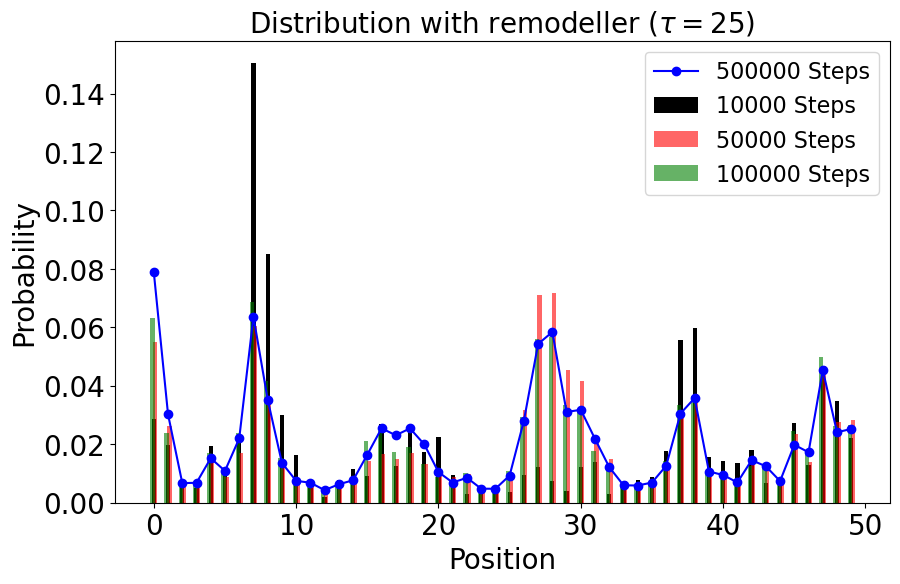

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(valid_pos, snapshots1[0], width=0.3, color='black', alpha=1, label=f'{checkpoints_4B[0]} Steps')
ax.bar(valid_pos+0.1, snapshots1[1], width=0.3, color='red', alpha=0.6, label=f'{checkpoints_4B[1]} Steps')
ax.bar(valid_pos-0.1, snapshots1[2], width=0.3, color='green', alpha=0.6, label=f'{checkpoints_4B[2]} Steps')
ax.plot(valid_pos, dist1, 'o-', color='blue', label='500000 Steps')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller $(\tau=25)$", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);

### Convergence for different rates

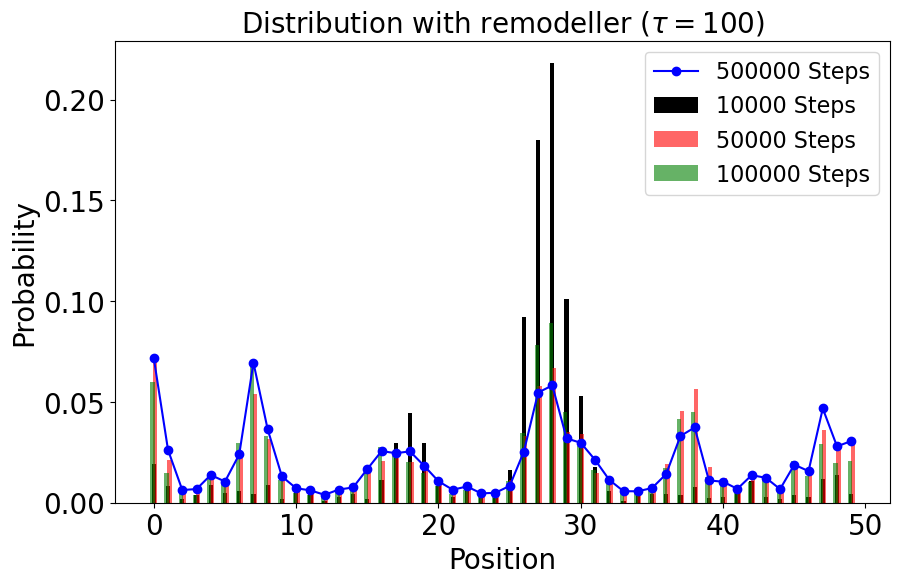

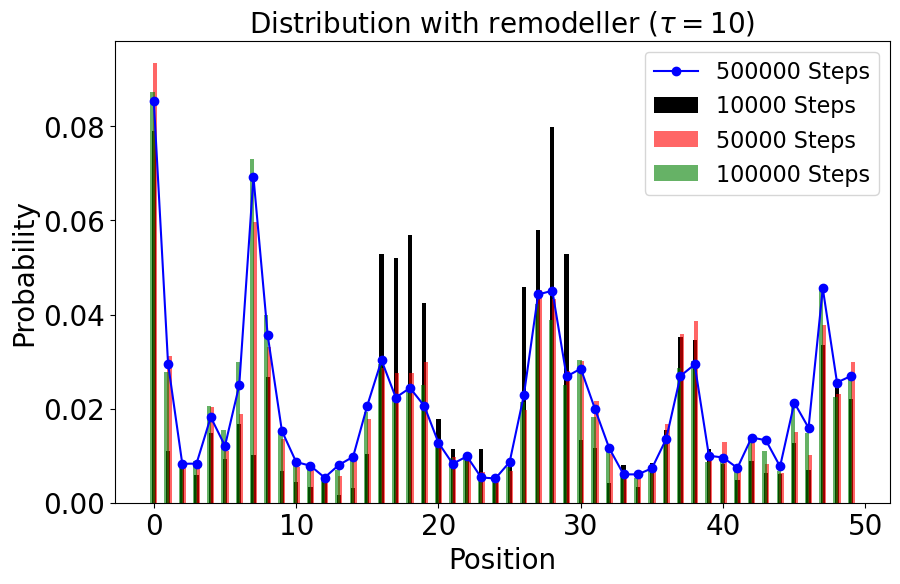

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(valid_pos, snapshots2[0], width=0.3, color='black', alpha=1, label=f'{checkpoints_4B[0]} Steps')
ax.bar(valid_pos+0.1, snapshots2[1], width=0.3, color='red', alpha=0.6, label=f'{checkpoints_4B[1]} Steps')
ax.bar(valid_pos-0.1, snapshots2[2], width=0.3, color='green', alpha=0.6, label=f'{checkpoints_4B[2]} Steps')
ax.plot(valid_pos, dist2, 'o-', color='blue', label='500000 Steps')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller $(\tau=100)$", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(valid_pos, snapshots3[0], width=0.3, color='black', alpha=1, label=f'{checkpoints_4B[0]} Steps')
ax.bar(valid_pos+0.1, snapshots3[1], width=0.3, color='red', alpha=0.6, label=f'{checkpoints_4B[1]} Steps')
ax.bar(valid_pos-0.1, snapshots3[2], width=0.3, color='green', alpha=0.6, label=f'{checkpoints_4B[2]} Steps')
ax.plot(valid_pos, dist3, 'o-', color='blue', label='500000 Steps')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller $(\tau=10)$", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);

### Comparing different rates (final distribution)

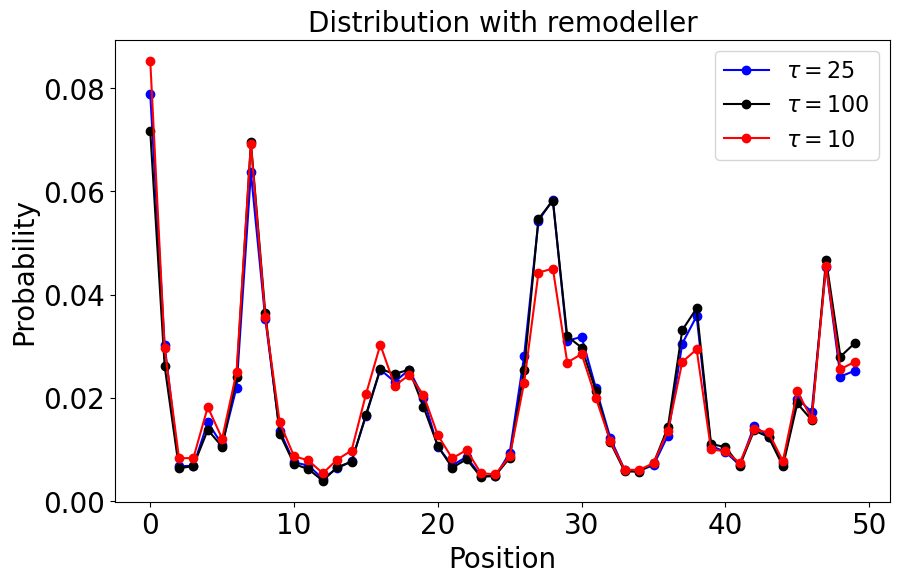

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(valid_pos, dist1, 'o-', color='blue', label=r'$\tau=25$')
ax.plot(valid_pos, dist2, 'o-', color='black', label=r'$\tau=100$')
ax.plot(valid_pos, dist3, 'o-', color='red', label=r'$\tau=10$')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);

### Convergence for bias

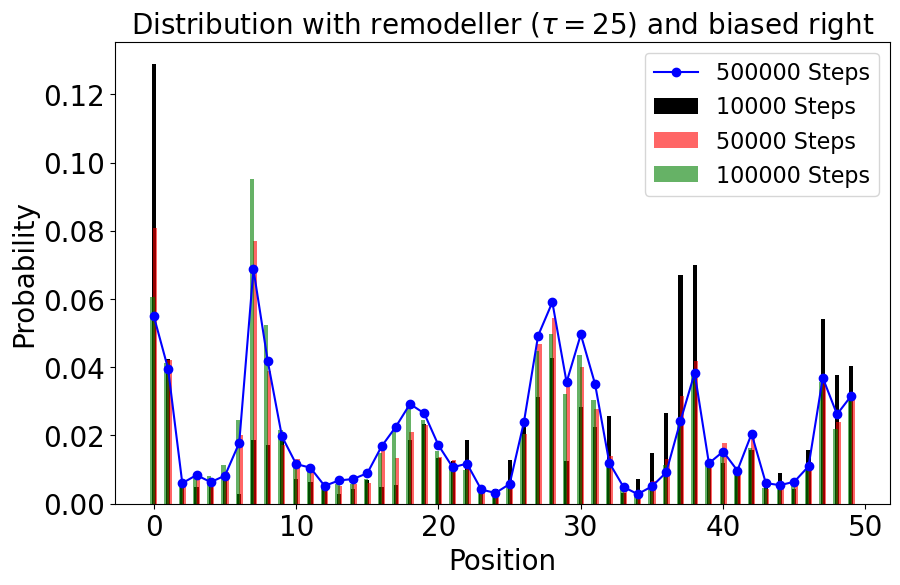

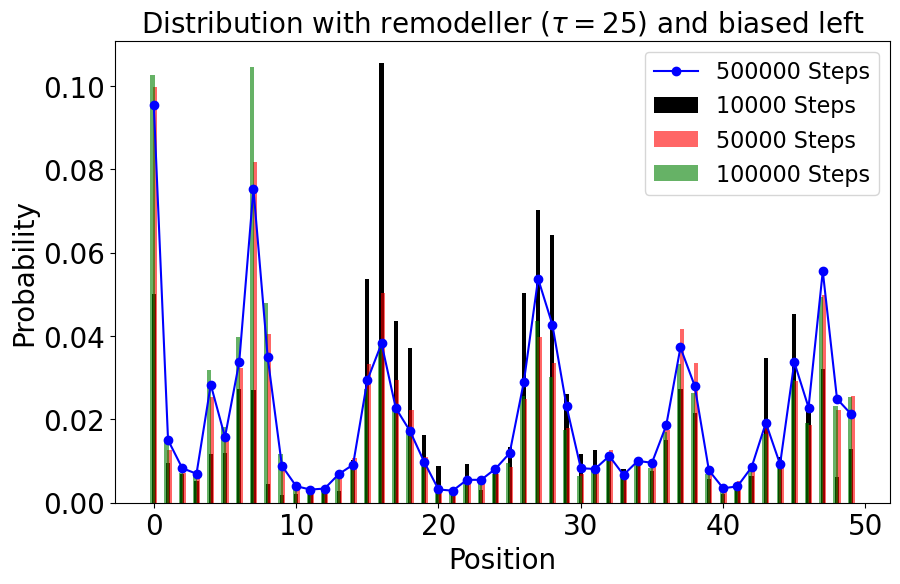

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(valid_pos, snapshots4[0], width=0.3, color='black', alpha=1, label=f'{checkpoints_4B[0]} Steps')
ax.bar(valid_pos+0.1, snapshots4[1], width=0.3, color='red', alpha=0.6, label=f'{checkpoints_4B[1]} Steps')
ax.bar(valid_pos-0.1, snapshots4[2], width=0.3, color='green', alpha=0.6, label=f'{checkpoints_4B[2]} Steps')
ax.plot(valid_pos, dist4, 'o-', color='blue', label='500000 Steps')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller $(\tau=25)$ and biased right", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(valid_pos, snapshots5[0], width=0.3, color='black', alpha=1, label=f'{checkpoints_4B[0]} Steps')
ax.bar(valid_pos+0.1, snapshots5[1], width=0.3, color='red', alpha=0.6, label=f'{checkpoints_4B[1]} Steps')
ax.bar(valid_pos-0.1, snapshots5[2], width=0.3, color='green', alpha=0.6, label=f'{checkpoints_4B[2]} Steps')
ax.plot(valid_pos, dist5, 'o-', color='blue', label='500000 Steps')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller $(\tau=25)$ and biased left", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);

### Comparing different biases (final distribution)

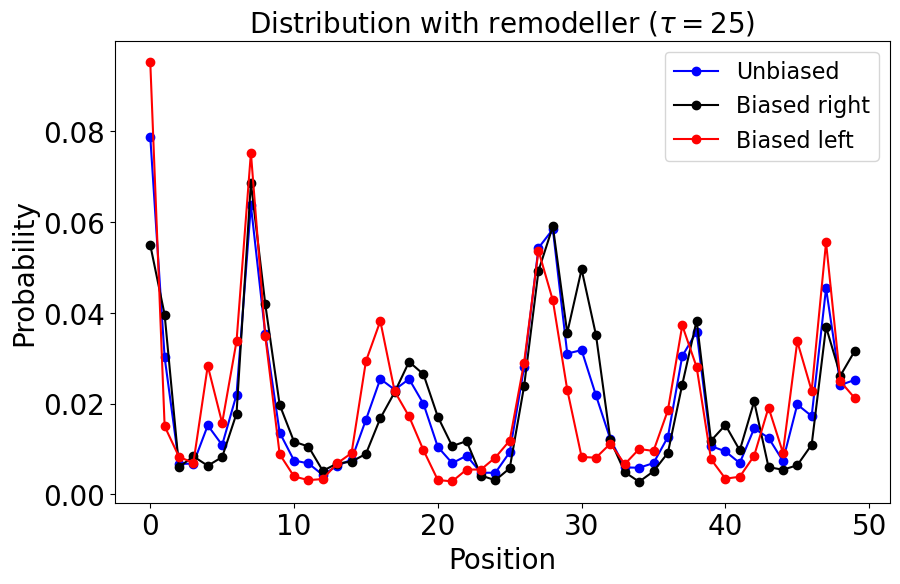

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(valid_pos, dist1, 'o-', color='blue', label='Unbiased')
ax.plot(valid_pos, dist4, 'o-', color='black', label='Biased right')
ax.plot(valid_pos, dist5, 'o-', color='red', label='Biased left')
ax.set_xlabel("Position", fontsize=20)
ax.set_ylabel("Probability", fontsize=20)
ax.set_title(r"Distribution with remodeller $(\tau=25)$", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(fontsize=16);